# Fun with Shortest Path Algorithms

This note explores various use cases of shortest path algorithms. In particular, we will search for the shortest path on grid-like graphs, which are common in many applications such as pathfinding in games, image processing and others.

## Grid Graph

An image with the shape (width, height) can be represented as a grid graph, where each pixel corresponds to a node in the graph. The edges between nodes can be defined based on the connectivity of adjacent pixels. For example, in a 4-connected grid, each pixel is connected to its four immediate neighbors (up, down, left, right). In an 8-connected grid, each pixel is also connected to its diagonal neighbors.

In [3]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import skimage
from ipycanvas import Canvas, MultiCanvas, hold_canvas
from IPython.display import display
from ipywidgets import widgets
# seed number for reproducibility
np.random.seed(42)

In [4]:
# generate a maze on a 4-connected grid graph with the shape maze_shape and a probability of p_edge or each edge to be removed
# the start node is always (0, 0) and the end node is always (maze_shape[0] - 1, maze_shape[1] - 1)
maze_shape = 10,10
p_edge = 0.5

def grid_graph_edges_4nh(maze_shape):
    edges = []
    for x in range(maze_shape[0]):
        for y in range(maze_shape[1]):
            u = (x, y)
            if x + 1 < maze_shape[0]:
                v = (x + 1, y)
                yield (u, v)
            if y + 1 < maze_shape[1]:
                v = (x, y + 1)
                yield (u, v)

def generate_maze_candidate(maze_shape, p_edge):
    g = nx.Graph()

    for x in range(maze_shape[0]):
        for y in range(maze_shape[1]):
            g.add_node((x, y))
    for u, v in grid_graph_edges_4nh(maze_shape):
        if np.random.rand() < p_edge:
            g.add_edge(u, v)
    return g

def draw_maze(g, maze_shape, pixel_size, layout={'width': '40%'}, display_canvas=True, output=None):
    canvas = Canvas(width=maze_shape[0] * pixel_size, height=maze_shape[1] * pixel_size, layout=layout)
    if display_canvas:
        display(canvas)

    with hold_canvas(canvas):

        canvas.stroke_width = 5
        canvas.stroke_style = 'rgba(0, 0, 0, 0.05)'
        # draw each pixel as a rectangle (just draw, no fill)
        for x in range(maze_shape[0]):
            for y in range(maze_shape[1]):
                cx = x * pixel_size
                cy = y * pixel_size
                canvas.stroke_rect(cx, cy, pixel_size, pixel_size)

        # draw the start and end nodes in a light blue color
        canvas.fill_style = 'lightblue'
        canvas.fill_rect(0, 0, pixel_size, pixel_size)
        canvas.fill_rect((maze_shape[0] - 1) * pixel_size, (maze_shape[1] - 1) * pixel_size, pixel_size, pixel_size)
        canvas.stroke_style = 'rgb(0, 0, 0)'
        
        for uv in grid_graph_edges_4nh(maze_shape):
            u, v = uv
            if output is not None:
                output.append(f"edge: {u} - {v}, exists: {g.has_edge(u, v)}")
            assert u in g.nodes, f"Node {u} is not in the graph"
            assert v in g.nodes, f"Node {v} is not in the graph"
            if not g.has_edge(u, v):

                x1, y1 = u
                x2, y2 = v
                
                # horizontal edge (will be seperated by a vertical line)
                if x1 != x2:
                    # vertical line!
                    yl0 = y1 * pixel_size
                    yl1 = yl0 + pixel_size
                    xl = (x1 + 1) * pixel_size
                    canvas.stroke_line(xl, yl0, xl, yl1)
                else:
                    # horizontal line
                    xl0 = x1 * pixel_size
                    xl1 = xl0 + pixel_size
                    yl = (y1 + 1) * pixel_size
                    canvas.stroke_line(xl0, yl, xl1, yl)
        
        # draw outline of the maze
        canvas.stroke_width = 15
        canvas.stroke_style = 'rgba(0, 0, 0, 1)'
        canvas.stroke_rect(0, 0, maze_shape[0] * pixel_size, maze_shape[1] * pixel_size)

    return canvas



In [5]:
maze = generate_maze_candidate(maze_shape, 0.1)
draw_maze(maze, maze_shape, 50);

Canvas(layout=Layout(width='40%'), width=500)

In [6]:
def generate_maze(maze_shape, p_edge, max_attempts=100, increment=0.01, silent=False):
    g = generate_maze_candidate(maze_shape, p_edge)
    # check if there is a path from the start node to the end node, if not, generate a new maze candidate until there is a path
    start_node = (0, 0)
    end_node = (maze_shape[0] - 1, maze_shape[1] - 1)
    attempts = 0
    found = False
    while not found:
        for _ in range(max_attempts):
            g = generate_maze_candidate(maze_shape, p_edge)
            if nx.has_path(g, start_node, end_node):
                found = True
                break
        if not found:
            p_edge = min(1, p_edge + increment)
            if not silent:
                print(f"No path found, increment p_edge to {p_edge:.2f} and trying again...")
    return g         
        
maze = generate_maze(maze_shape, 0.1)
draw_maze(maze, maze_shape, 50);

No path found, increment p_edge to 0.11 and trying again...
No path found, increment p_edge to 0.12 and trying again...
No path found, increment p_edge to 0.13 and trying again...
No path found, increment p_edge to 0.14 and trying again...
No path found, increment p_edge to 0.15 and trying again...
No path found, increment p_edge to 0.16 and trying again...
No path found, increment p_edge to 0.17 and trying again...
No path found, increment p_edge to 0.18 and trying again...
No path found, increment p_edge to 0.19 and trying again...
No path found, increment p_edge to 0.20 and trying again...
No path found, increment p_edge to 0.21 and trying again...
No path found, increment p_edge to 0.22 and trying again...
No path found, increment p_edge to 0.23 and trying again...
No path found, increment p_edge to 0.24 and trying again...
No path found, increment p_edge to 0.25 and trying again...
No path found, increment p_edge to 0.26 and trying again...
No path found, increment p_edge to 0.27 

Canvas(layout=Layout(width='40%'), width=500)

In [7]:
# lets try to find the shortest path from the start node to the end node using bfs
maze_shape = 10,10
maze = generate_maze(maze_shape, 0.5)
canvas = draw_maze(maze, maze_shape, 50)

start_node = (0, 0)
end_node = (maze_shape[0] - 1, maze_shape[1] - 1)
shortest_path = nx.shortest_path(maze, start_node, end_node)

def draw_path(canvas, path, pixel_size):
    with hold_canvas(canvas):
        canvas.stroke_style = 'red'
        canvas.line_width = 3
        for i in range(len(path) - 1):
            x1, y1 = path[i]
            x2, y2 = path[i + 1]
            cx1 = x1 * pixel_size + pixel_size // 2
            cy1 = y1 * pixel_size + pixel_size // 2
            cx2 = x2 * pixel_size + pixel_size // 2
            cy2 = y2 * pixel_size + pixel_size // 2
            canvas.stroke_line(cx1, cy1, cx2, cy2)
draw_path(canvas, shortest_path, 50)


Canvas(layout=Layout(width='40%'), width=500)

# The longest shortest path



IntProgress(value=0, description='Progress:', max=2000)

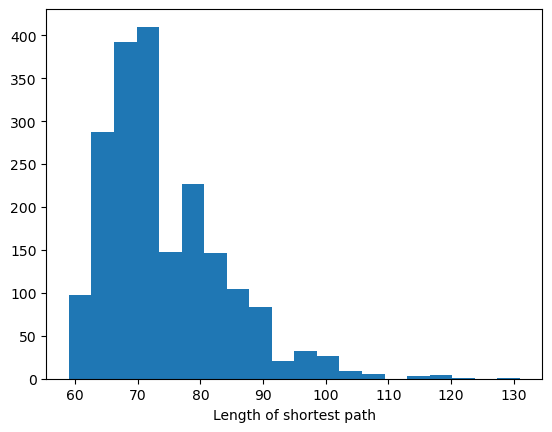

In [ ]:
from ipywidgets import IntProgress
from ipywidgets import HBox, Layout, Label, VBox
# seed number for reproducibility
np.random.seed(42)

n_mazes = 200
progress = IntProgress(value=0, min=0, max=n_mazes, description='Progress:')
display(progress)

maze_size = (30,30)
p_edge = 0.5
lengths = []
hardest_maze = None
easiest_maze = None
longest_length = 0
shortest_length = float('inf')
longest_shortest_path = None
shortest_shortest_path = None
i_easiest = None
i_hardest = None

for i in range(n_mazes):
    progress.value = i + 1
    maze = generate_maze(maze_size, p_edge, silent=True)
    start_node = (0, 0)
    end_node = (maze_size[0] - 1, maze_size[1] - 1)
    shortest_path = nx.shortest_path(maze, start_node, end_node)
    length = len(shortest_path)
    lengths.append(length)
    if hardest_maze is None or length > longest_length:
        hardest_maze = maze.copy()
        longest_length = length
        longest_shortest_path = list(shortest_path)
        i_hardest = i

    if easiest_maze is None or length < shortest_length:
        easiest_maze = maze.copy()
        shortest_length = length
        shortest_shortest_path = list(shortest_path)
        i_easiest = i

canvas_easiest = draw_maze(easiest_maze, maze_size, 20, layout={'width': '100%'}, display_canvas=False)
draw_path(canvas_easiest, shortest_shortest_path, 20)

canvas_hardest = draw_maze(hardest_maze, maze_size, 20, layout={'width': '100%'}, display_canvas=False)
draw_path(canvas_hardest, longest_shortest_path, 20)    


# display histogram of lengths
plt.hist(lengths, bins=20)
plt.xlabel('Length of shortest path')

# Create labels for the canvases
label_easiest = Label(value=f'Easiest Maze (i={i_easiest}, length={shortest_length})')
label_hardest = Label(value=f'Hardest Maze (i={i_hardest}, length={longest_length})')

# Create VBox containers with an explicit width to prevent them from 
# collapsing or expanding unexpectedly
vbox_layout = Layout(width='45%', align_items='center')

vbox_easiest = VBox([label_easiest, canvas_easiest], layout=vbox_layout)
vbox_hardest = VBox([label_hardest, canvas_hardest], layout=vbox_layout)

# Use justify_content='space-between' to push them to the sides, 
# or keep 'gap' with fixed-width children.
display(HBox(
    [vbox_easiest, vbox_hardest], 
    layout=Layout(width='100%', justify_content='space-around')
))




In [9]:
# create graph with 8-connected pixels
def eight_connected_grid_graph(shape, edge_weight_fn):
    
    def yield_edges():
        for x in range(shape[0]):
            for y in range(shape[1]):
                for dx in (-1, 0, 1):
                    for dy in (-1, 0, 1):
                        if dx == 0 and dy == 0:
                            continue
                        nx_, ny_ = x + dx, y + dy
                        if 0 <= nx_ < shape[0] and 0 <= ny_ < shape[1]:
                            if nx_ > x or (nx_ == x and ny_ > y):
                                yield (x, y), (nx_, ny_), edge_weight_fn(x, y, nx_, ny_)
    g = nx.Graph()
    for u, v, w in yield_edges():
        g.add_edge(u, v, weight=w)
    return g



# Avoid obstacles by finding the shortest path in a graph

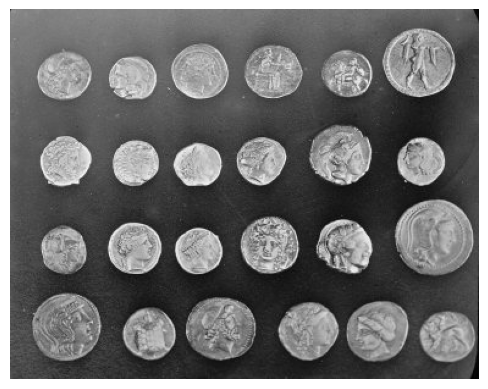

In [10]:
# sample image
img = skimage.data.coins()
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

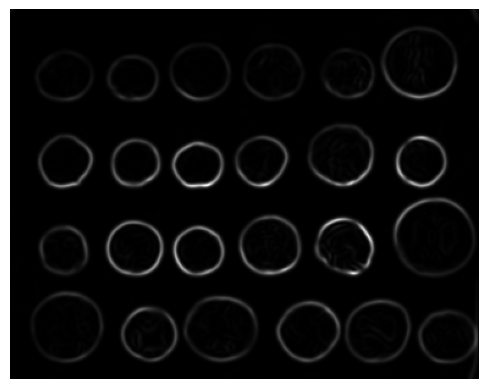

In [11]:
#  use gradient magnitude as edge weights
smoothed = skimage.filters.gaussian(img, sigma=2)
edges = skimage.filters.sobel(smoothed)
edges = edges / np.max(edges)

# use some exponential to make the weights more pronounced
weights = np.exp(edges * 4)


# plot height map
plt.imshow(weights, cmap='gray')
plt.axis('off')
plt.show()

In [12]:
# take max
def edge_weight_fn(x1, y1, x2, y2):
    return max(weights[x1, y1], weights[x2, y2]) + 0.5
g = eight_connected_grid_graph(weights.shape[0:2], edge_weight_fn)

# interactive ipycanvas widget to allow for clicking on the graph
from ipycanvas import Canvas, hold_canvas

canvas = Canvas(width=weights.shape[1], height=weights.shape[0])
points = []
draw_img = img

def draw_point(x, y, color='red', r=3):
    canvas.fill_style = color
    canvas.fill_circle(x, y, r)

def on_click(x, y):
    global points
    node = (int(y), int(x))
    if len(points) == 2:
        points = []
        canvas.put_image_data(draw_img, 0, 0)
    points.append(node)

    draw_point(x, y, 'red' if len(points) == 1 else 'blue')

    if len(points) == 2:
        path = nx.shortest_path(g, source=points[0], target=points[1], weight='weight')
        with hold_canvas(canvas):
            for i in range(len(path) - 1):
                y1, x1 = path[i]
                y2, x2 = path[i + 1]
                canvas.stroke_style = 'green'
                canvas.line_width = 2
                canvas.stroke_line(x1, y1, x2, y2)

canvas.on_mouse_down(on_click)
canvas.put_image_data(img, 0, 0)
display(canvas)

Canvas(height=303, width=384)

# Magic Siccours

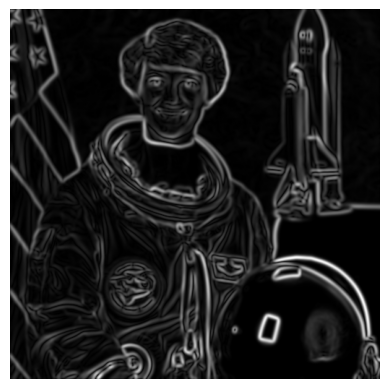

In [13]:

# load image (astronaut)
astronaut = skimage.data.astronaut()

smoothed = skimage.filters.gaussian(astronaut, sigma=2)

# add channel wise sobel filter responses to get a height map
sobel_r = skimage.filters.sobel(smoothed[:, :, 0])
sobel_g = skimage.filters.sobel(smoothed[:, :, 1]) 
sobel_b = skimage.filters.sobel(smoothed[:, :, 2])

# show
height_map = sobel_r + sobel_g + sobel_b
plt.imshow(height_map, cmap='gray')
plt.axis('off')
plt.show()



In [14]:

# output widget 
from ipywidgets import Output
out = Output()
display(out)
# create graph and edge weight function for astronaut image
def edge_weight_fn_astronaut(x1, y1, x2, y2):

    y1, x1 = x1, y1
    y2, x2 = x2, y2
    
    max_gradient = max(height_map[x1, y1], height_map[x2, y2])
    # a high gradient should have a low weight.
    # so lets use some negative exponential to make the weights more pronounced
    return np.exp(-max_gradient * 15.0) + 0.5

g_astronaut = eight_connected_grid_graph(height_map.shape[0:2], edge_weight_fn_astronaut)

# interactive canvas for segmentation
multi_canvas = MultiCanvas(3, width=height_map.shape[1], height=height_map.shape[0])
canvas_image = multi_canvas[0]
canvas_stored_seg = multi_canvas[1]
canvas_temp = multi_canvas[2]
seg_points = []
seg_path = []
draw_astronaut = astronaut


canvas_image.put_image_data(draw_astronaut, 0, 0)

def draw_point_seg(canvas, x, y, color='red', r=3 ):
    canvas.fill_style = color
    canvas.fill_circle(x, y, r)

def draw_line_seg(canvas, x1, y1, x2, y2, color='green', width=2):
    canvas.stroke_style = color
    canvas.line_width = width
    canvas.stroke_line(x1, y1, x2, y2)

is_down = False
ctrl_points = []


def draw_shortest_path(canvas, start, end):
    path = nx.shortest_path(g_astronaut, source=start, target=end, weight='weight')
    with hold_canvas(canvas):
        for i in range(len(path) - 1):
            x1, y1 = path[i]
            x2, y2 = path[i + 1]
            draw_line_seg(canvas, x1, y1, x2, y2)

last_x, last_y = 0, 0
@out.capture()
def on_mouse_move(x, y):
    x, y = int(x), int(y)
    try:
        global is_down, ctrl_points, last_x, last_y
        if is_down and len(ctrl_points) > 0 and (x, y) != (last_x, last_y):
            # clear temp canvas
            canvas_temp.clear()

            # draw shortest path from last ctrl point to current mouse position
            draw_shortest_path(canvas_temp, ctrl_points[-1], (x, y))

            last_x, last_y = x, y
    except Exception as e:
        print(f"Error in on_mouse_move: {e}")
@out.capture()
def on_mouse_down(x, y):
    x, y = int(x), int(y)
    try:
        global is_down, ctrl_points
        is_down = True

        # clear temp canvas
        canvas_temp.clear()

        # draw point
        draw_point_seg(canvas_temp, x, y)

        # draw shortest path from last ctrl point to current mouse position if there is a ctrl point already
        if len(ctrl_points) > 0:
            draw_shortest_path(canvas_temp, ctrl_points[-1], (x, y))

    except Exception as e:
        print(f"Error in on_mouse_down: {e}")
        

@out.capture()
def on_mouse_up(x, y):
    x, y = int(x), int(y)
    try:
        global is_down, ctrl_points
        is_down = False
        ctrl_points.append((x, y))
        # draw point to permanent canvas
        draw_point_seg(canvas_stored_seg, x, y)

        # draw shortest path from last ctrl point to current mouse position if there are 2 ctrl points already
        if len(ctrl_points) >= 2:   
            draw_shortest_path(canvas_stored_seg, ctrl_points[-2], ctrl_points[-1])
    except Exception as e:
        print(f"Error in on_mouse_up: {e}")


@out.capture()
def on_mouse_out(x, y):
    try:
        global is_down
        is_down = False
    except Exception as e:
        print(f"Error in on_mouse_out: {e}")

canvas_temp.on_mouse_down(on_mouse_down)
canvas_temp.on_mouse_move(on_mouse_move)
canvas_temp.on_mouse_up(on_mouse_up)
canvas_temp.on_mouse_out(on_mouse_out)
display(multi_canvas)

Output()

MultiCanvas(height=512, width=512)